# Dashboard Hasil — Prediksi Kurs USD/IDR (JISDOR)

Notebook ini menampilkan **semua hasil evaluasi** yang tersimpan di folder ini (`results/`):
- Naive baseline klasifikasi (`naive_baseline_results.json`) & regresi (`naive_baseline_regression_results.json`)
- Metrik terpadu (`unified_metrics_baseline.json`, dari `src/models/metrics.py`)
- XGBoost Gabungan TS+NLP (`04_*`), TS-only (`05_*`), NLP-only (`06_*`)
- Gambar: confusion matrix, predicted-vs-actual, feature importance, distribusi target

**Dua angka naive yang berbeda (penting!):**
- *Full-split* (120/121 baris val/test): Macro-F1 Test **0.3637**, RMSE Test **57.4694** — lower bound kanonis.
- *Same-rows* (177/179 baris, hanya hari yang punya fitur berita): Macro-F1 Test **0.3562**, RMSE Test **51.1231** — dipakai di CSV perbandingan agar apel-vs-apel dengan XGBoost.

Cara pakai ulang: `jupyter nbconvert --to notebook --execute results/00_tampilkan_semua_hasil.ipynb --inplace`


In [1]:
%matplotlib inline
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.metrics import confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Notebook tinggal di results/ -> file cukup "./...".
# Kalau dieksekusi dari repo root, jatuh ke "results/".
RES = Path(".")
if not (RES / "06_nlp_only_comparison.csv").exists():
    RES = Path("results")
assert (RES / "06_nlp_only_comparison.csv").exists(), "File hasil tidak ditemukan!"

LABELS = ["NAIK", "STABIL", "TURUN"]

def load_json(name):
    with open(RES / name, encoding="utf-8") as f:
        return json.load(f)

def show_png(name, caption):
    print(f"\n### {caption}  (`{name}`)")
    display(Image(filename=str(RES / name)))


## 1. Inventaris file hasil

In [2]:
rows = []
for p in sorted(RES.iterdir()):
    if p.is_file() and p.suffix in (".json", ".csv", ".png"):
        rows.append({"file": p.name, "ukuran_KB": round(p.stat().st_size / 1024, 1)})
inv = pd.DataFrame(rows)
print(f"Total {len(inv)} artefak hasil.")
display(inv)


Total 22 artefak hasil.


,file,ukuran_KB
0,04_all_results.json,3.7
1,04_gabungan_comparison.csv,0.8
2,04_gabungan_confusion_matrix.png,35.6
3,04_gabungan_feature_importance.png,84.1
4,04_gabungan_predicted_vs_actual.png,156.0
5,04_gabungan_results.json,3.7
6,04_model_comparison.csv,0.8
7,05_ts_only_comparison.csv,1.0
8,05_ts_only_confusion_matrix.png,34.4
9,05_ts_only_predicted_vs_actual.png,182.8


## 2. Perbandingan klasifikasi — Macro-F1 (primer)

Sumber: `06_nlp_only_comparison.csv` (superset: memuat Naive + ketiga varian XGBoost, dihitung pada baris yang sama sehingga fair).

accuracy           kappa         macro_f1  \
split                              test     val    test     val     test   
model                                                                      
Naive Persistence of Direction   0.3687  0.3785  0.0326  0.0603   0.3562   
Naive Majority-Class             0.4302  0.3898  0.0000  0.0000   0.2005   
XGBoost TS-only                  0.3687  0.3333  0.0486 -0.0023   0.3626   
XGBoost NLP-only                 0.2961  0.3333 -0.0095  0.0157   0.2856   
XGBoost Gabungan (TS+NLP)        0.3017  0.4068 -0.0571  0.1046   0.2938   

                                        
split                              val  
model                                   
Naive Persistence of Direction  0.3713  
Naive Majority-Class            0.1870  
XGBoost TS-only                 0.3245  
XGBoost NLP-only                0.3334  
XGBoost Gabungan (TS+NLP)       0.4009

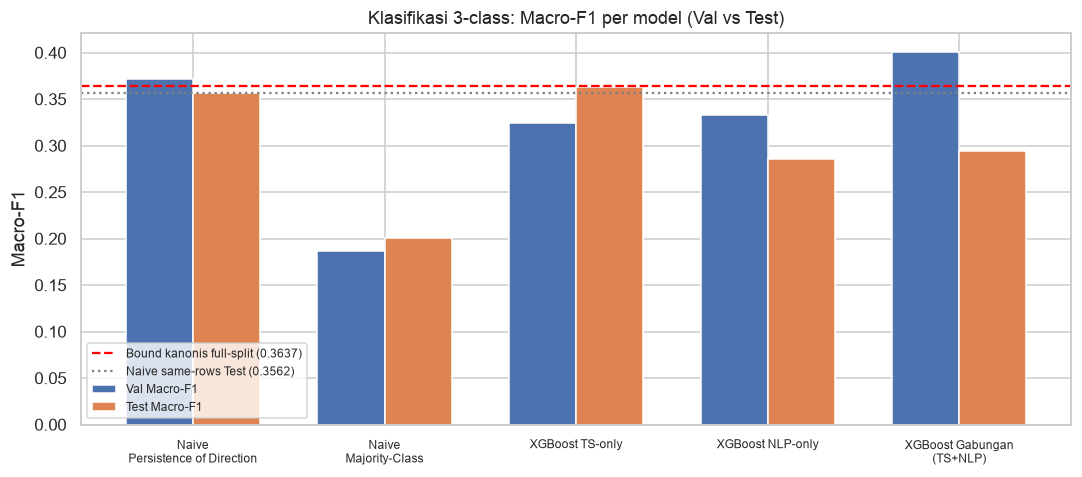

In [3]:
comp = pd.read_csv(RES / "06_nlp_only_comparison.csv")
clf = comp[comp.task == "clf"].copy()
order = ["Naive Persistence of Direction", "Naive Majority-Class",
         "XGBoost TS-only", "XGBoost NLP-only", "XGBoost Gabungan (TS+NLP)"]
clf["model"] = pd.Categorical(clf["model"], categories=order, ordered=True)
clf = clf.sort_values(["split", "model"])

tab_clf = clf.pivot_table(index="model", columns="split",
                          values=["accuracy", "macro_f1", "kappa"], observed=False)
display(tab_clf.round(4))

fig, ax = plt.subplots(figsize=(10, 4.5))
x = range(len(order))
w = 0.35
val_f1 = [clf[(clf.model == m) & (clf.split == "val")]["macro_f1"].iloc[0] for m in order]
tst_f1 = [clf[(clf.model == m) & (clf.split == "test")]["macro_f1"].iloc[0] for m in order]
ax.bar([i - w / 2 for i in x], val_f1, w, label="Val Macro-F1")
ax.bar([i + w / 2 for i in x], tst_f1, w, label="Test Macro-F1")
ax.axhline(0.3637, ls="--", c="red", label="Bound kanonis full-split (0.3637)")
ax.axhline(0.3562, ls=":", c="gray", label="Naive same-rows Test (0.3562)")
ax.set_xticks(list(x), [m.replace(" (TS+NLP)", "\n(TS+NLP)").replace("Naive ", "Naive\n") for m in order], fontsize=8)
ax.set_ylabel("Macro-F1")
ax.set_title("Klasifikasi 3-class: Macro-F1 per model (Val vs Test)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 3. Perbandingan regresi — RMSE (primer), skill, directional hit

Target: RMSE Test < bound kanonis full-split **57.4694**; pada subset same-rows, naive = **51.1231** (skill dihitung terhadap angka ini).

,model,split,rmse,mae,mape,skill_vs_naive,directional_hit
5,Naive Persistence (Random Walk),test,51.1231,38.5419,0.2214,0.0000,NaN
13,XGBoost TS-only,test,50.9977,38.1829,0.2193,0.0025,0.5978
9,XGBoost NLP-only,test,50.7325,37.8720,0.2174,0.0076,0.5978
17,XGBoost Gabungan (TS+NLP),test,50.8200,37.8530,0.2173,0.0059,0.5978
2,Naive Persistence (Random Walk),val,56.0099,40.8701,0.2479,0.0000,NaN
11,XGBoost TS-only,val,55.6477,40.5737,0.2462,0.0065,0.5367
8,XGBoost NLP-only,val,55.8495,41.0800,0.2492,0.0029,0.5085
15,XGBoost Gabungan (TS+NLP),val,55.6733,40.8703,0.2480,0.0060,0.5424


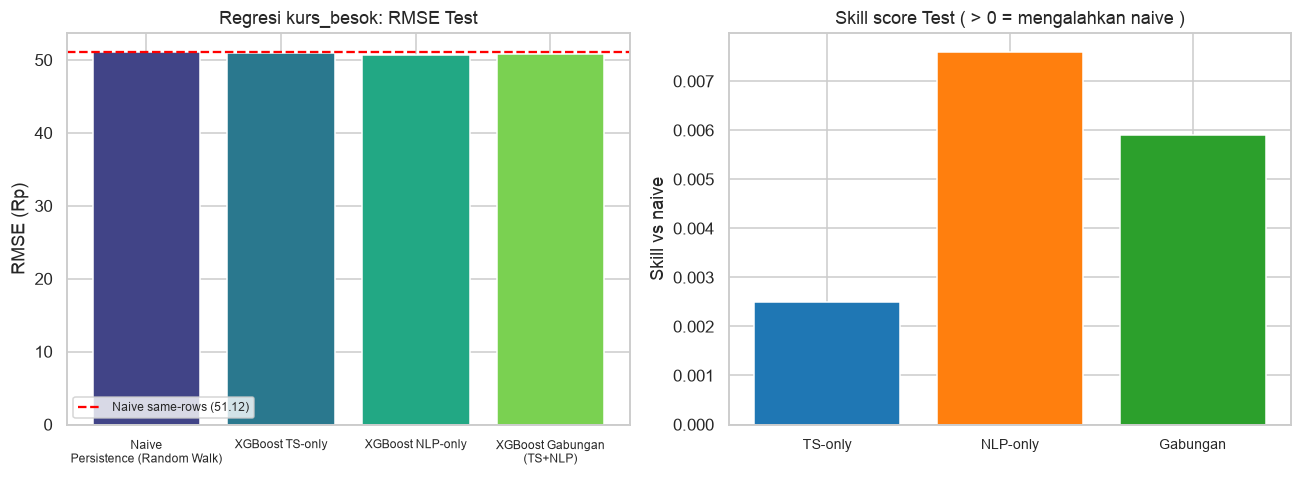

In [4]:
reg = comp[comp.task == "reg"].copy()
order_reg = ["Naive Persistence (Random Walk)", "XGBoost TS-only",
             "XGBoost NLP-only", "XGBoost Gabungan (TS+NLP)"]
reg["model"] = pd.Categorical(reg["model"], categories=order_reg, ordered=True)
reg = reg.sort_values(["split", "model"])
display(reg[["model", "split", "rmse", "mae", "mape", "skill_vs_naive", "directional_hit"]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
tst = reg[reg.split == "test"].set_index("model").loc[order_reg]
axes[0].bar(range(len(order_reg)), tst["rmse"], color=sns.color_palette("viridis", len(order_reg)))
axes[0].axhline(51.1231, ls="--", c="red", label="Naive same-rows (51.12)")
axes[0].set_xticks(range(len(order_reg)), [m.replace(" (TS+NLP)", "\n(TS+NLP)").replace("Naive ", "Naive\n") for m in order_reg], fontsize=8)
axes[0].set_ylabel("RMSE (Rp)")
axes[0].set_title("Regresi kurs_besok: RMSE Test")
axes[0].legend(fontsize=8)
xgb_only = tst.loc[["XGBoost TS-only", "XGBoost NLP-only", "XGBoost Gabungan (TS+NLP)"]]
axes[1].bar(range(3), xgb_only["skill_vs_naive"], color=["tab:blue", "tab:orange", "tab:green"])
axes[1].axhline(0, c="black", lw=0.8)
axes[1].set_xticks(range(3), ["TS-only", "NLP-only", "Gabungan"], fontsize=9)
axes[1].set_ylabel("Skill vs naive")
axes[1].set_title("Skill score Test ( > 0 = mengalahkan naive )")
fig.tight_layout()
plt.show()


## 4. Detail klasifikasi per model — per-kelas P/R/F1 + confusion matrix

Confusion matrix digambar ulang dari JSON (urutan label NAIK/STABIL/TURUN) agar mandiri dari PNG.


XGBoost Gabungan (TS+NLP)  (`04_gabungan_results.json`)
Fitur: {'ts': ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_std5'], 'lexicon': ['vader_title_mean', 'vader_body_mean', 'vader_body_min', 'vader_neg_share', 'lm_negative_mean', 'lm_positive_mean', 'lm_uncertainty_mean', 'lm_litigious_mean', 'lm_constraining_mean', 'lm_net_mean', 'no_news'], 'tfidf_svd': 50}
--- val: acc=0.4068 bal=0.4054 macroF1=0.4009 kappa=0.1046


,precision,recall,f1-score,support
NAIK,0.4286,0.4348,0.4317,69.0
STABIL,0.4444,0.2909,0.3516,55.0
TURUN,0.3662,0.4906,0.4194,53.0


--- test: acc=0.3017 bal=0.2969 macroF1=0.2938 kappa=-0.0571


,precision,recall,f1-score,support
NAIK,0.3788,0.3247,0.3497,77.0
STABIL,0.2619,0.2200,0.2391,50.0
TURUN,0.2535,0.3462,0.2927,52.0


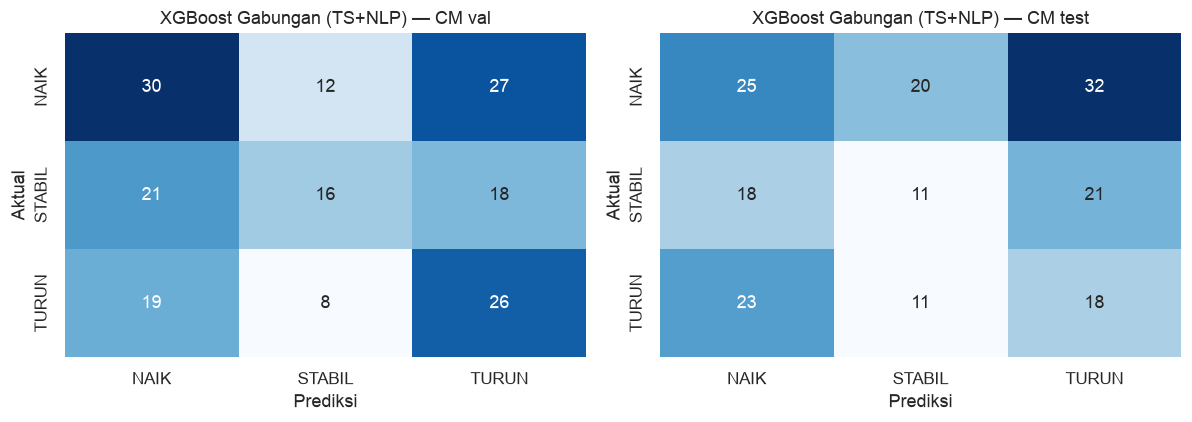


XGBoost TS-only (tanpa NLP)  (`05_ts_only_results.json`)
Fitur: {'ts': ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_std5']}
--- val: acc=0.3333 bal=0.3379 macroF1=0.3245 kappa=-0.0023


,precision,recall,f1-score,support
NAIK,0.3182,0.3043,0.3111,69.0
STABIL,0.4074,0.2000,0.2683,55.0
TURUN,0.3214,0.5094,0.3942,53.0


--- test: acc=0.3687 bal=0.3705 macroF1=0.3626 kappa=0.0486


,precision,recall,f1-score,support
NAIK,0.4355,0.3506,0.3885,77.0
STABIL,0.3590,0.2800,0.3146,50.0
TURUN,0.3205,0.4808,0.3846,52.0


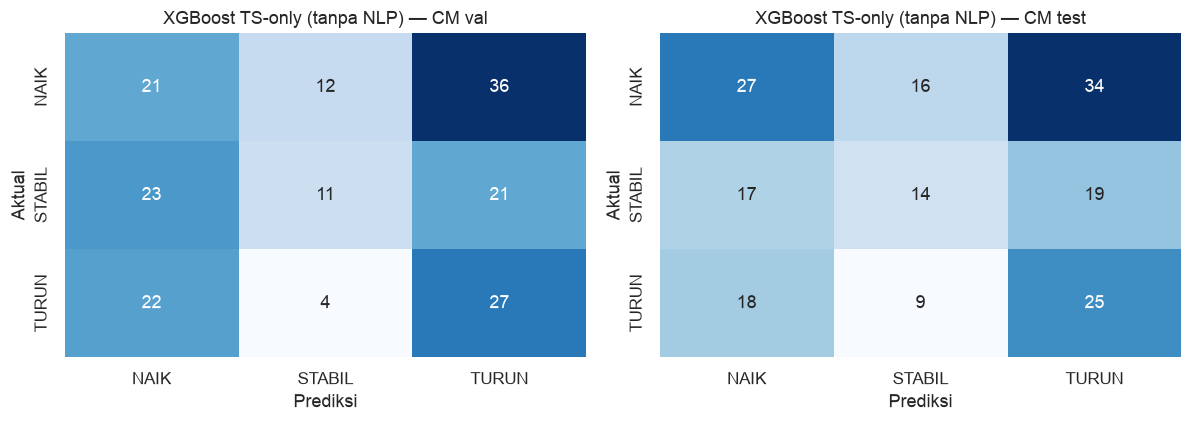


XGBoost NLP-only (tanpa kurs)  (`06_nlp_only_results.json`)
Fitur: {'lexicon': ['vader_title_mean', 'vader_body_mean', 'vader_body_min', 'vader_neg_share', 'lm_negative_mean', 'lm_positive_mean', 'lm_uncertainty_mean', 'lm_litigious_mean', 'lm_constraining_mean', 'lm_net_mean', 'no_news'], 'tfidf_svd': 50}
--- val: acc=0.3333 bal=0.3456 macroF1=0.3334 kappa=0.0157


,precision,recall,f1-score,support
NAIK,0.4000,0.2029,0.2692,69.0
STABIL,0.2619,0.4000,0.3165,55.0
TURUN,0.3966,0.4340,0.4144,53.0


--- test: acc=0.2961 bal=0.3292 macroF1=0.2856 kappa=-0.0095


,precision,recall,f1-score,support
NAIK,0.3636,0.1039,0.1616,77.0
STABIL,0.3038,0.4800,0.3721,50.0
TURUN,0.2692,0.4038,0.3231,52.0


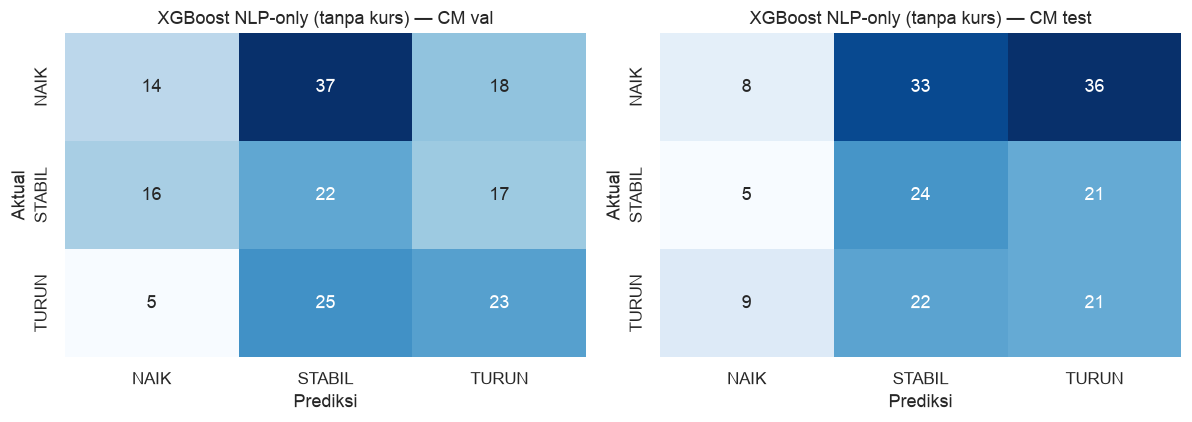

In [5]:
specs = [
    ("XGBoost Gabungan (TS+NLP)", "04_gabungan_results.json"),
    ("XGBoost TS-only (tanpa NLP)", "05_ts_only_results.json"),
    ("XGBoost NLP-only (tanpa kurs)", "06_nlp_only_results.json"),
]

for title, fname in specs:
    d = load_json(fname)
    print(f"\n{'=' * 70}\n{title}  (`{fname}`)")
    print(f"Fitur: {d.get('features')}")
    for split in ("val", "test"):
        r = d["classification"][split]
        rep = pd.DataFrame({k: v for k, v in r["classification_report"].items() if k in LABELS}).T
        print(f"--- {split}: acc={r['accuracy']} bal={r['balanced_accuracy']} "
              f"macroF1={r['macro_f1']} kappa={r.get('kappa')}")
        display(rep.round(4))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, split in zip(axes, ("val", "test")):
        cm = d["classification"][split]["confusion_matrix"]
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                    xticklabels=LABELS, yticklabels=LABELS)
        ax.set_xlabel("Prediksi")
        ax.set_ylabel("Aktual")
        ax.set_title(f"{title} — CM {split}")
    fig.tight_layout()
    plt.show()


## 5. Gambar tersimpan — confusion matrix, prediksi-vs-aktual, feature importance


### XGBoost Gabungan — confusion matrix (Test)  (`04_gabungan_confusion_matrix.png`)


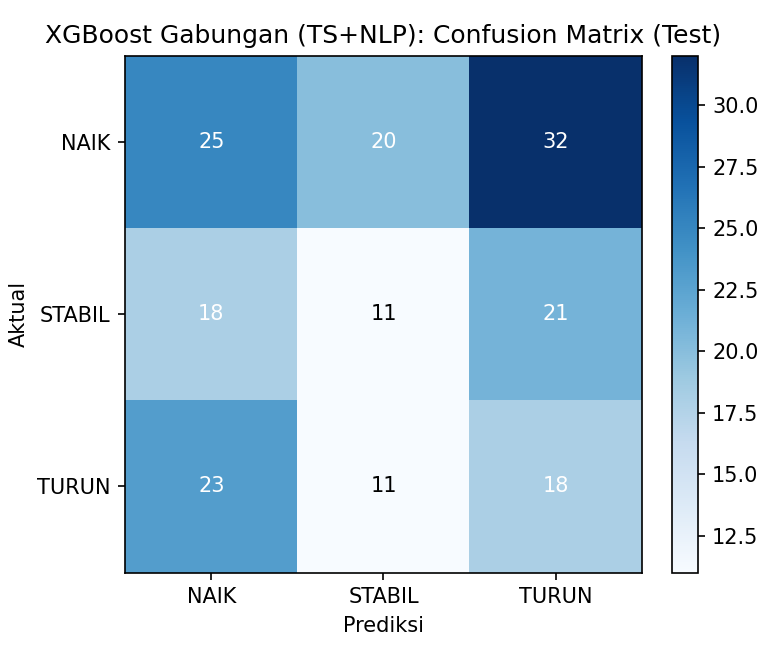


### XGBoost TS-only — confusion matrix (Test)  (`05_ts_only_confusion_matrix.png`)


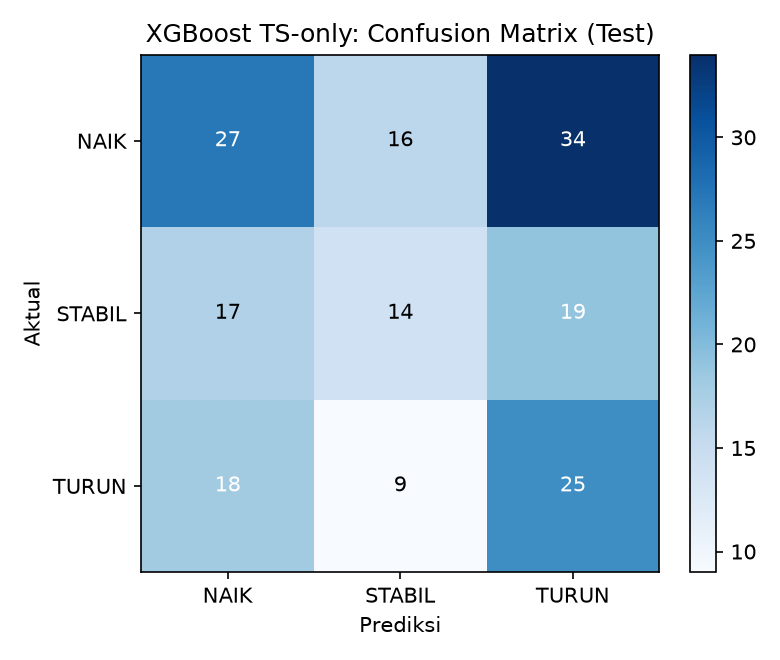


### XGBoost NLP-only — confusion matrix (Test)  (`06_nlp_only_confusion_matrix.png`)


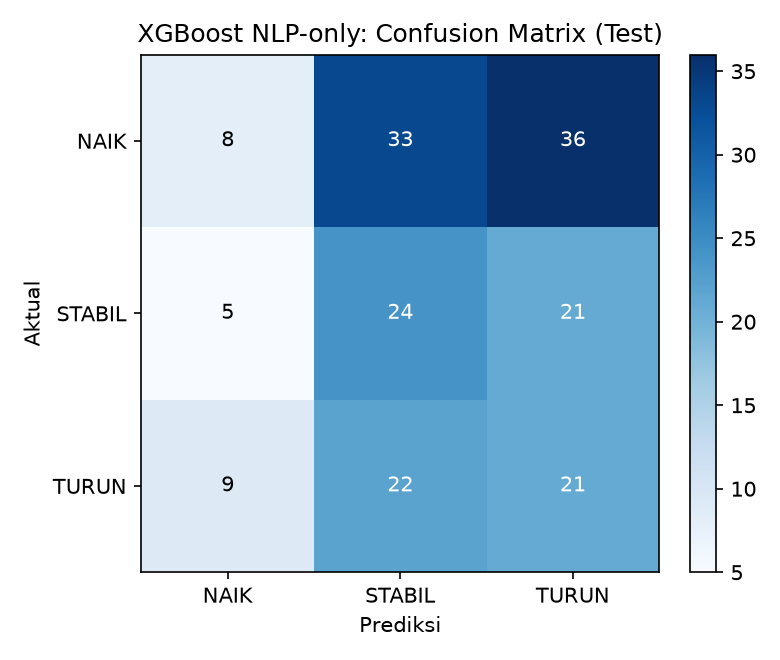


### XGBoost Gabungan — prediksi vs aktual (regresi)  (`04_gabungan_predicted_vs_actual.png`)


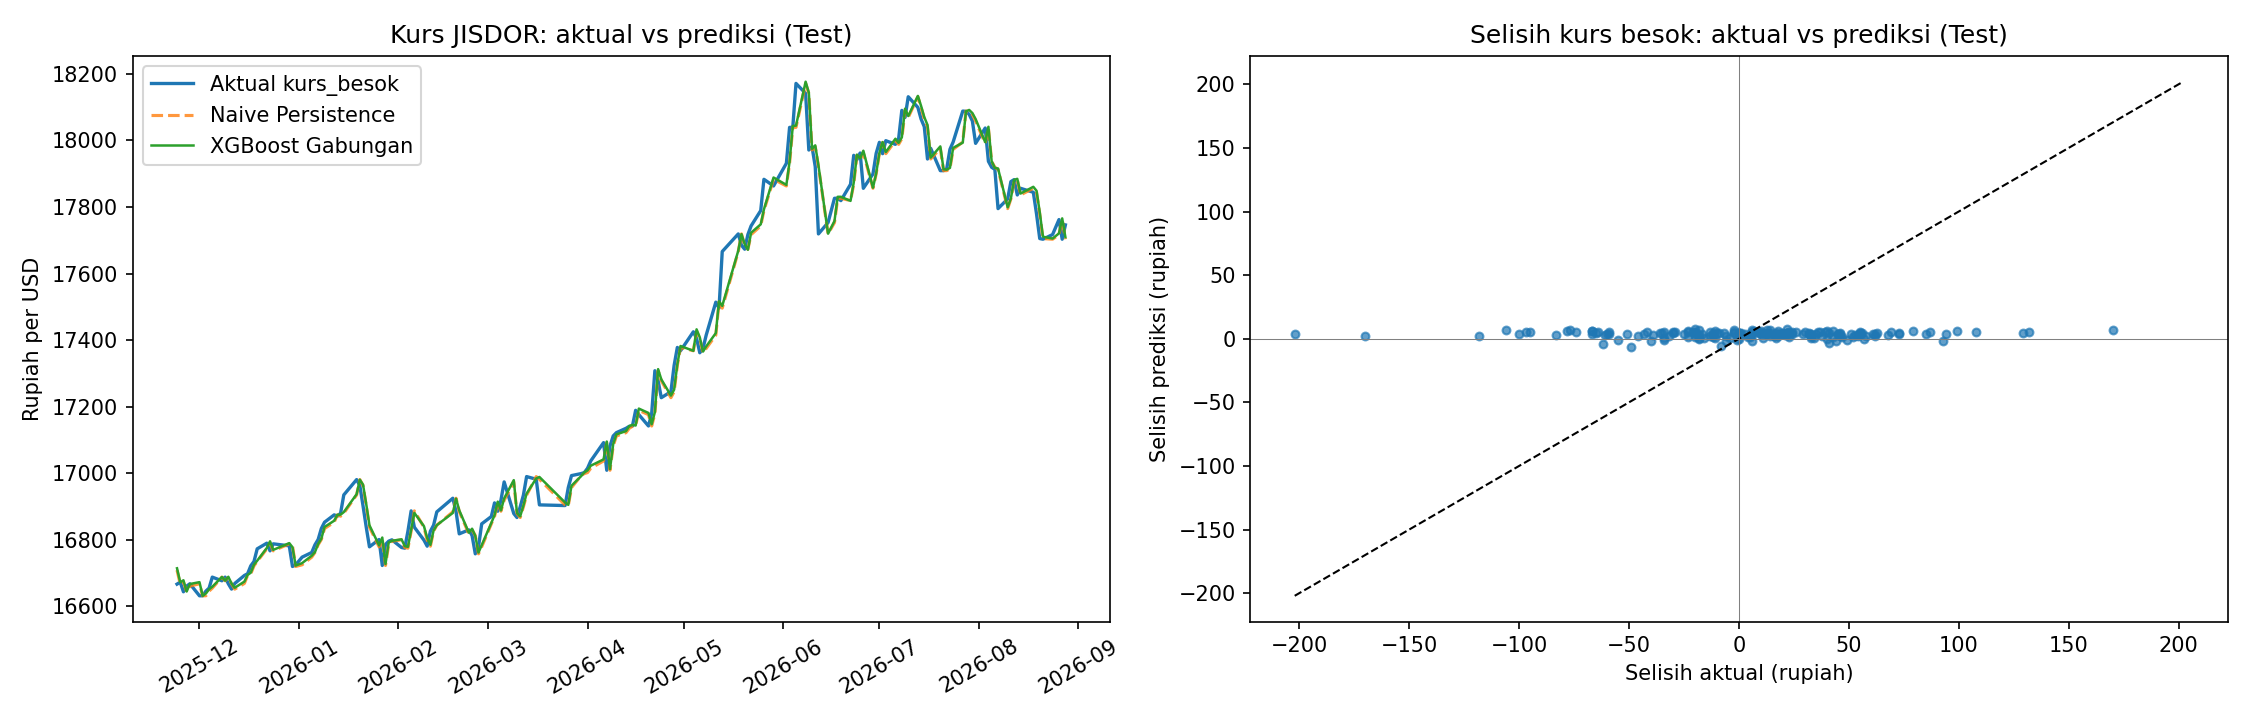


### XGBoost TS-only — prediksi vs aktual (regresi)  (`05_ts_only_predicted_vs_actual.png`)


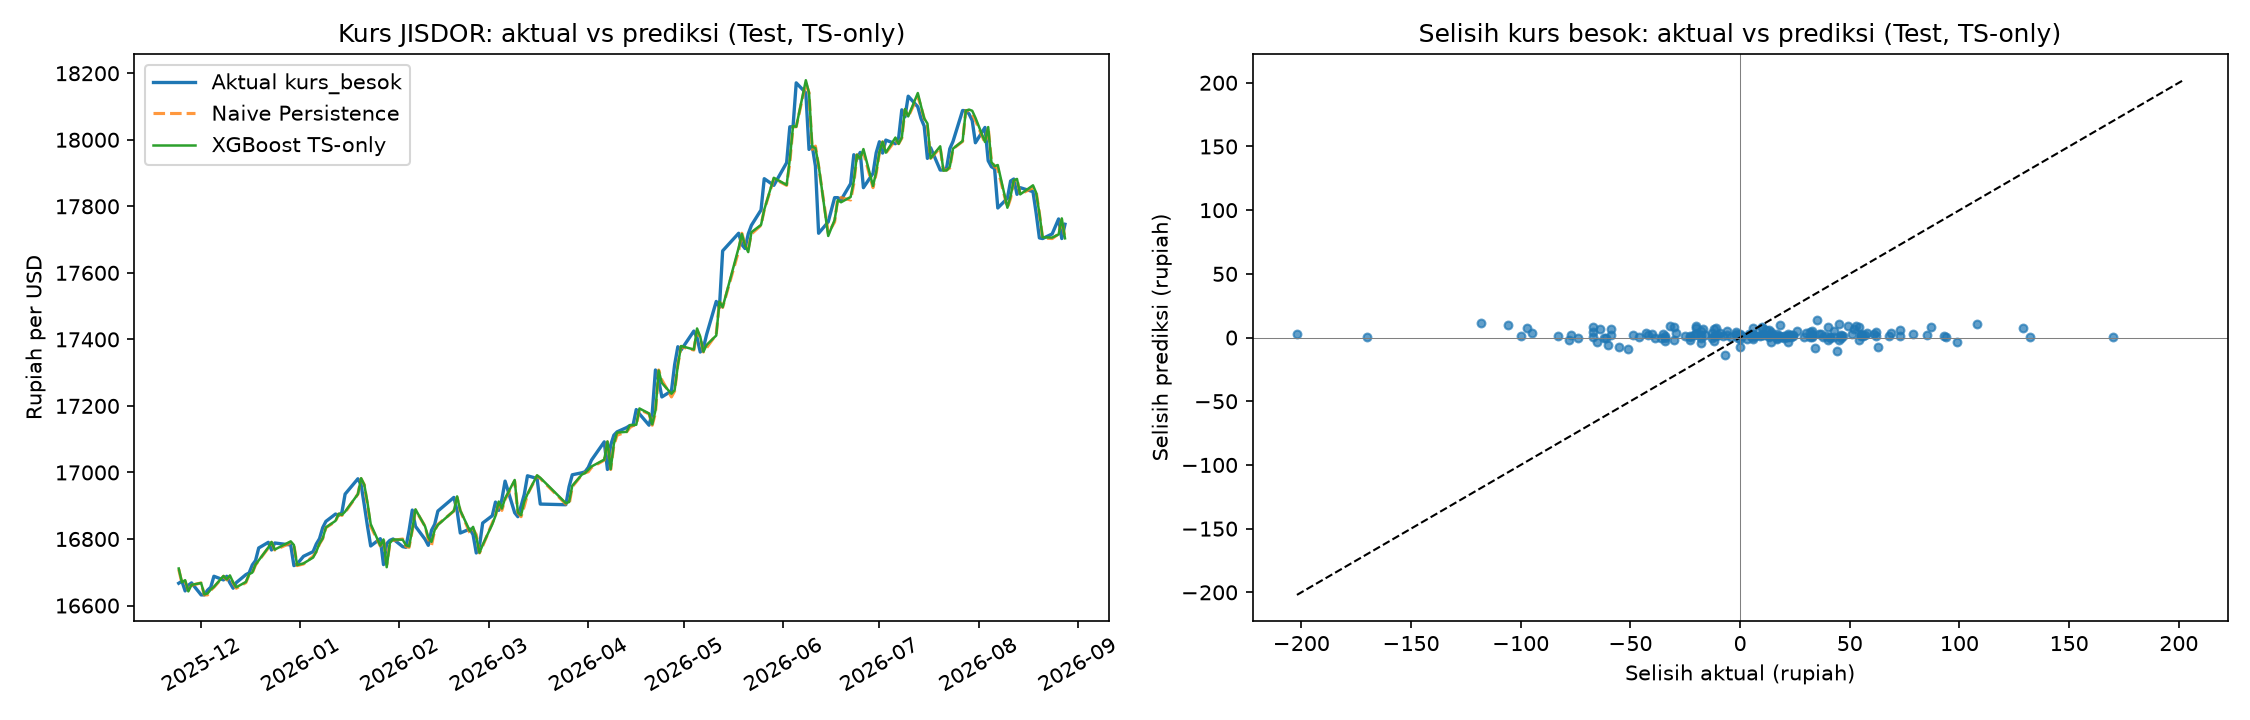


### XGBoost Gabungan — feature importance  (`04_gabungan_feature_importance.png`)


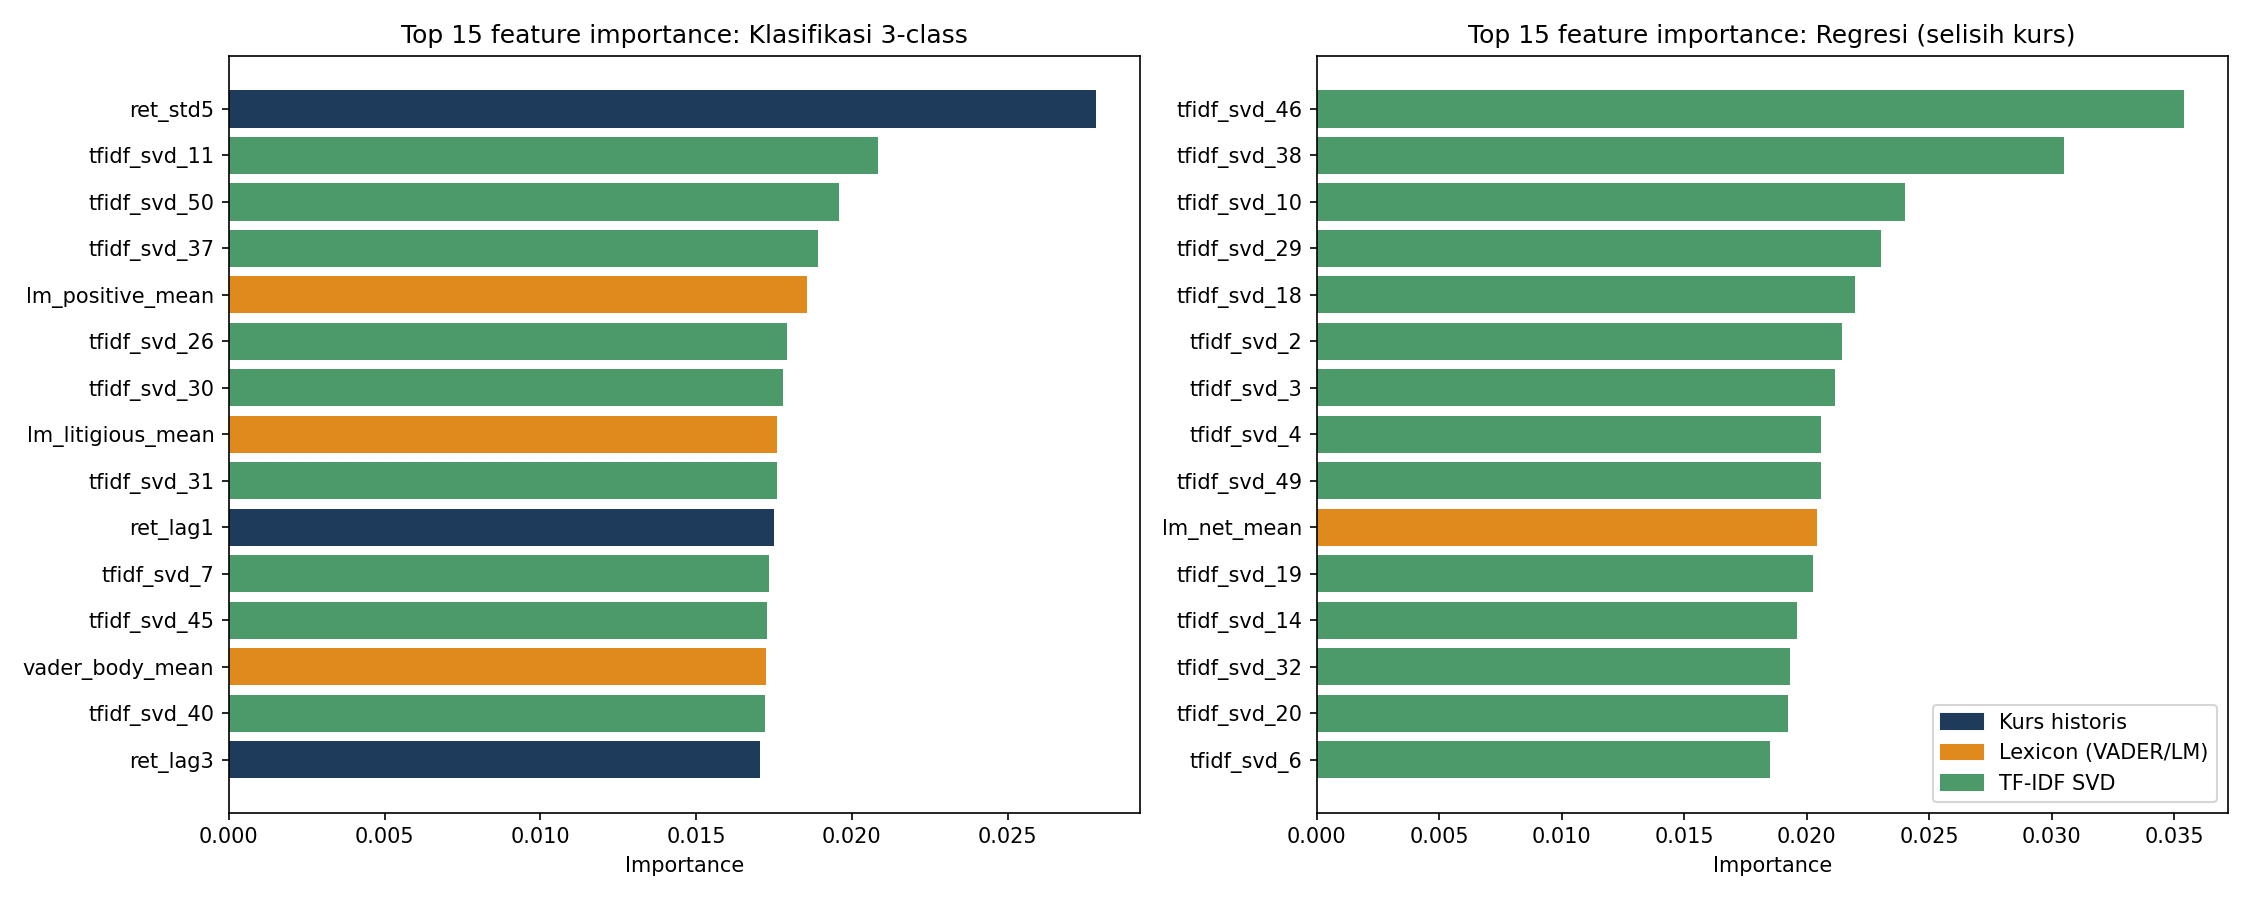

In [6]:
for fname, cap in [
    ("04_gabungan_confusion_matrix.png", "XGBoost Gabungan — confusion matrix (Test)"),
    ("05_ts_only_confusion_matrix.png", "XGBoost TS-only — confusion matrix (Test)"),
    ("06_nlp_only_confusion_matrix.png", "XGBoost NLP-only — confusion matrix (Test)"),
    ("04_gabungan_predicted_vs_actual.png", "XGBoost Gabungan — prediksi vs aktual (regresi)"),
    ("05_ts_only_predicted_vs_actual.png", "XGBoost TS-only — prediksi vs aktual (regresi)"),
    ("04_gabungan_feature_importance.png", "XGBoost Gabungan — feature importance"),
]:
    p = RES / fname
    if p.exists():
        show_png(fname, cap)
    else:
        print(f"(tidak ada: {fname})")


## 6. Naive baseline full-split (bound kanonis)

`naive_baseline_results.json` + `unified_metrics_baseline.json` dihitung pada **seluruh** baris split (val 119–120, test 121) — bukan subset same-rows. Inilah angka pembanding resmi di README.

Lower bound klasifikasi: Macro-F1 Test > 0.3637
Lower bound regresi    : RMSE Test < 57.4694
  clf val  Persistence of Direction   acc=0.3782 macroF1=0.3539
  clf val  Majority-Class             acc=0.3613 macroF1=0.1770
  clf test Persistence of Direction   acc=0.3802 macroF1=0.3637
  clf test Majority-Class             acc=0.4463 macroF1=0.2057
  reg val  Persistence (Random Walk)  rmse=37.5053 mae=28.5294
  reg test Persistence (Random Walk)  rmse=57.4694 mae=43.5950

### Naive baseline — confusion matrix  (`naive_baseline_confusion_matrix.png`)


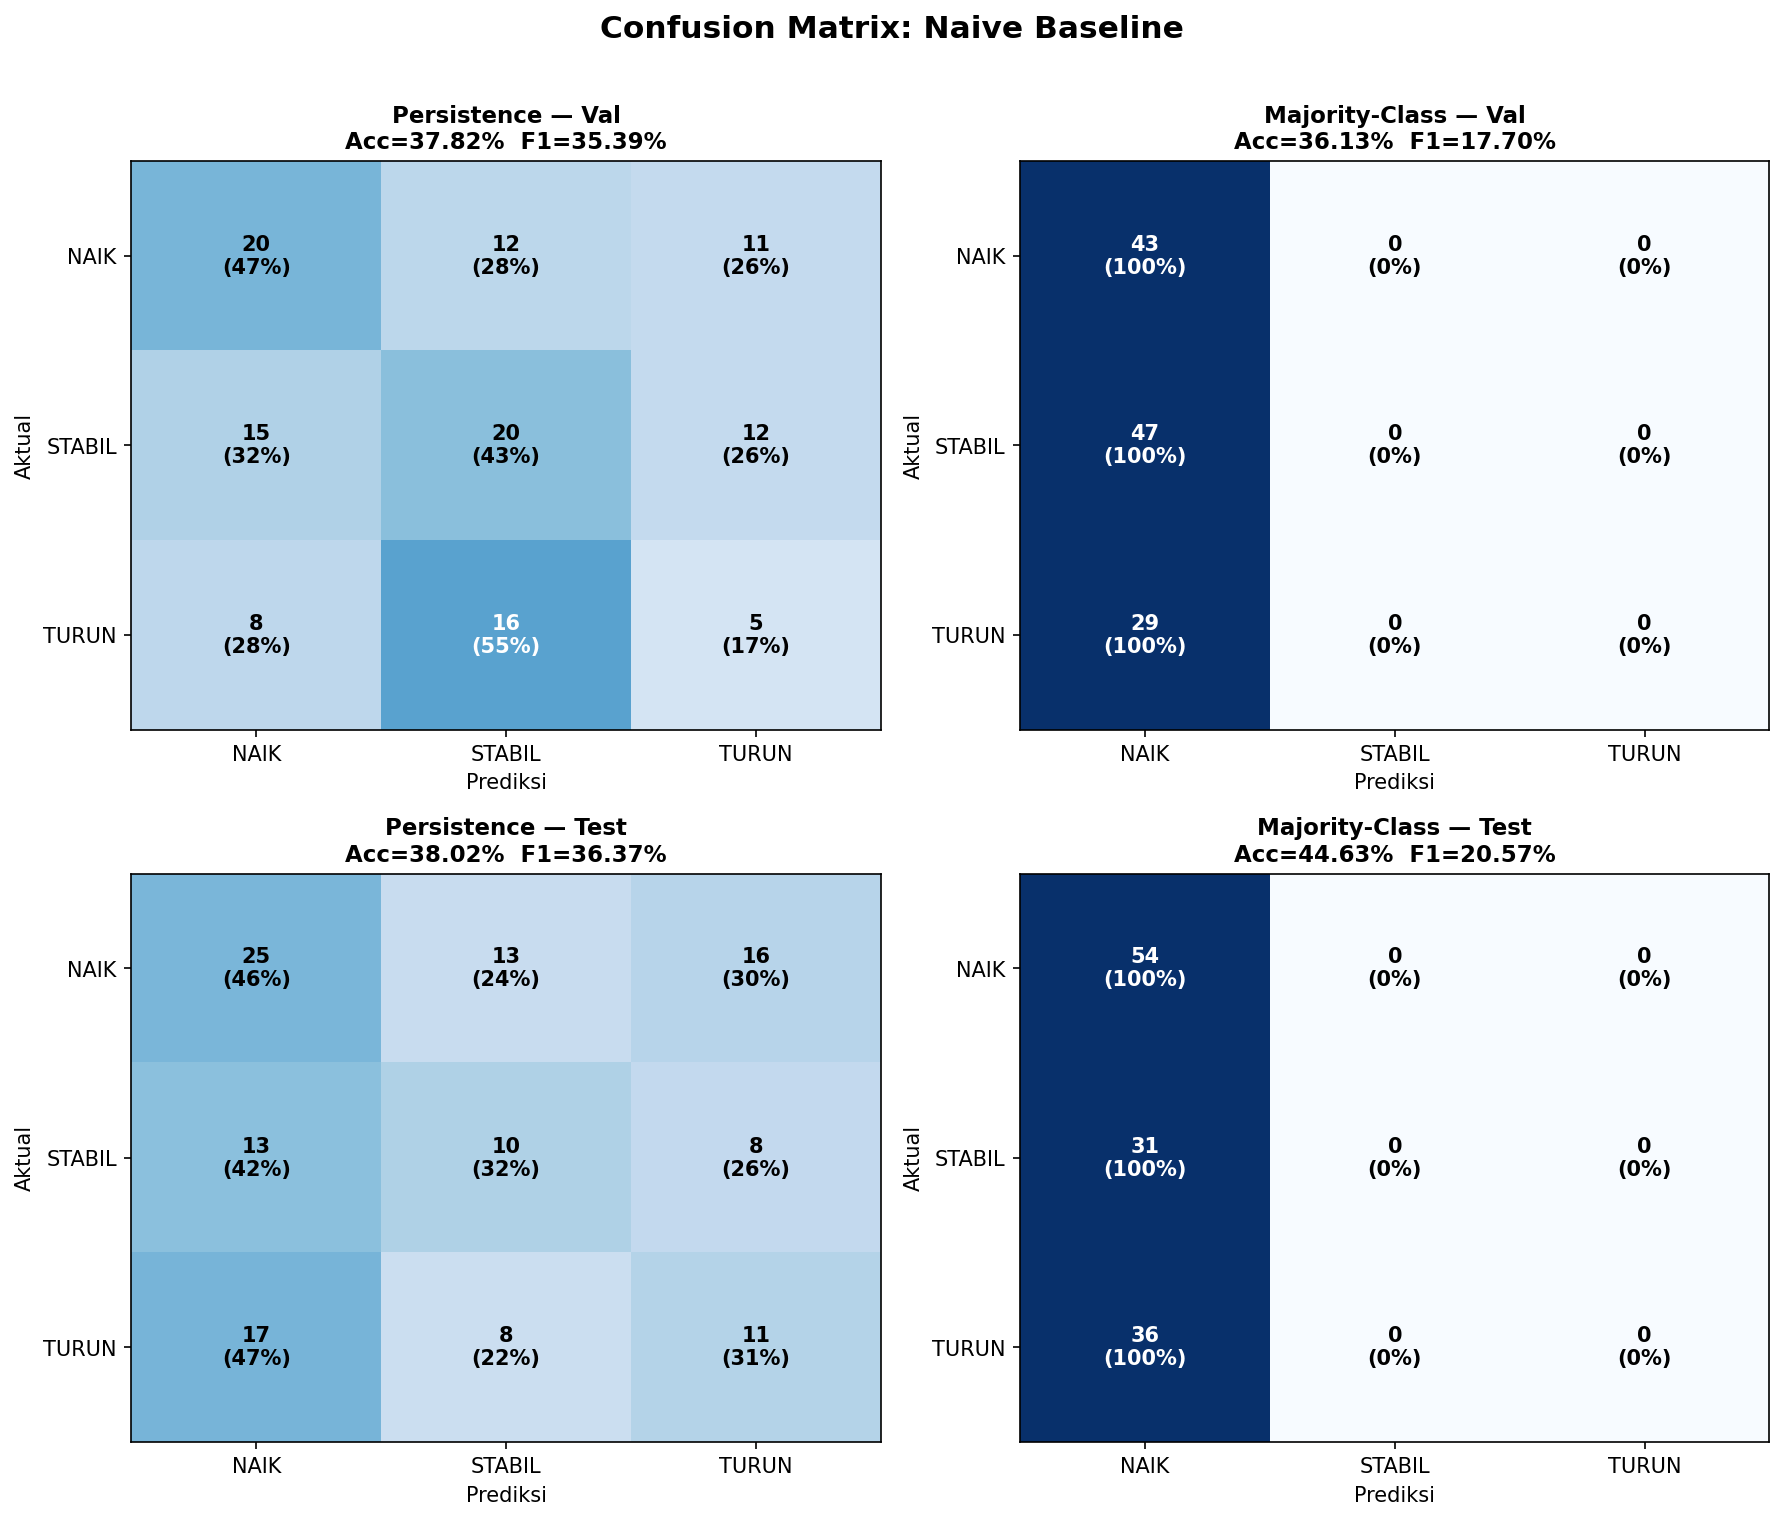


### Naive baseline — perbandingan klasifikasi  (`naive_baseline_comparison.png`)


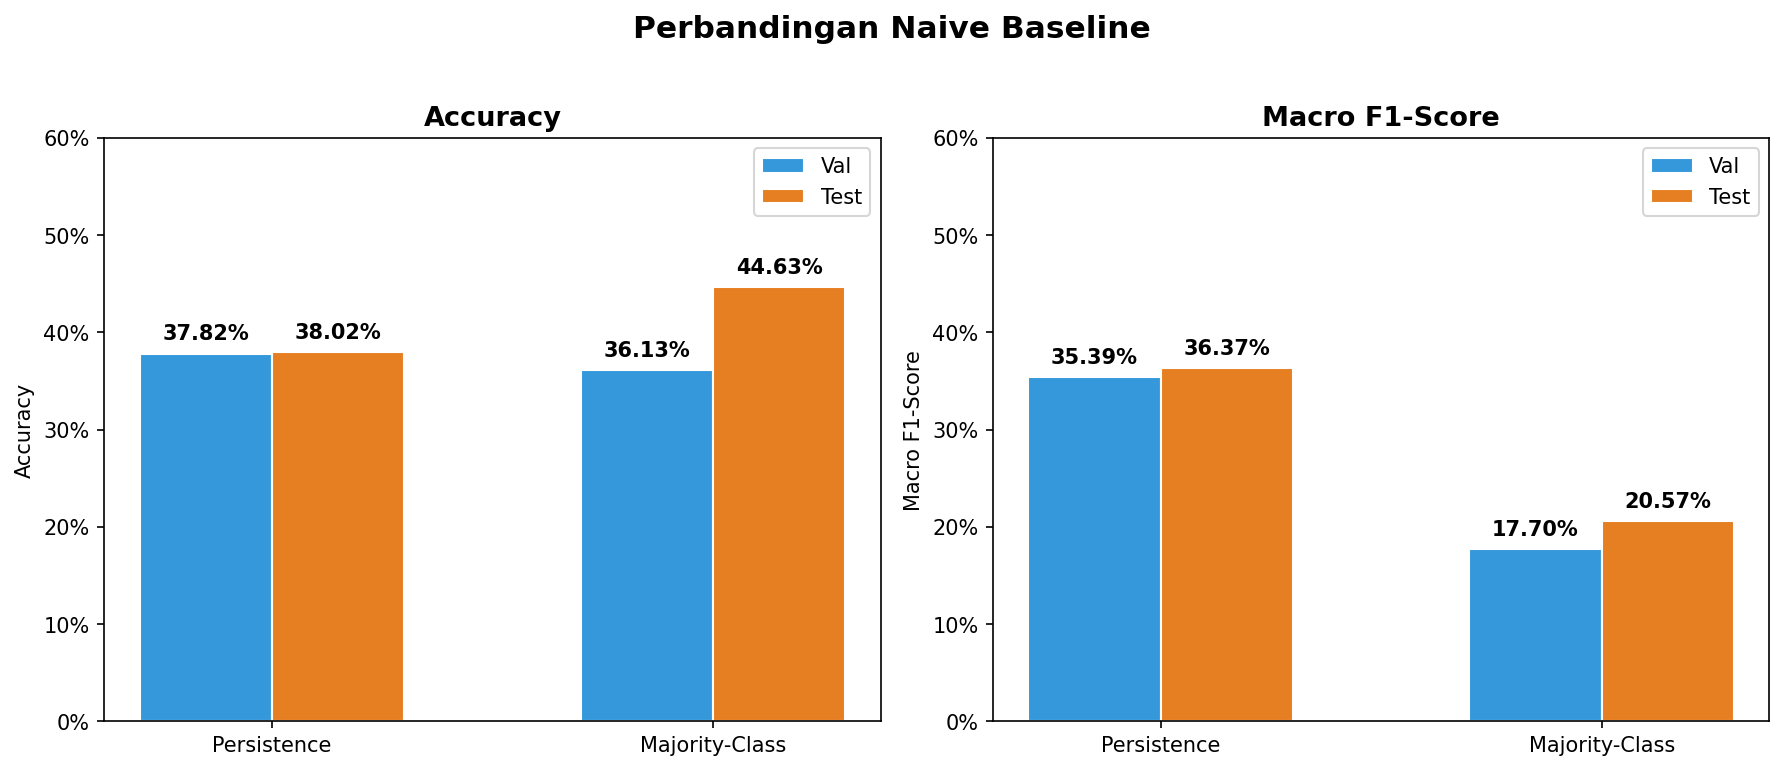


### Naive baseline — prediksi vs aktual (regresi)  (`naive_baseline_regression_prediction.png`)


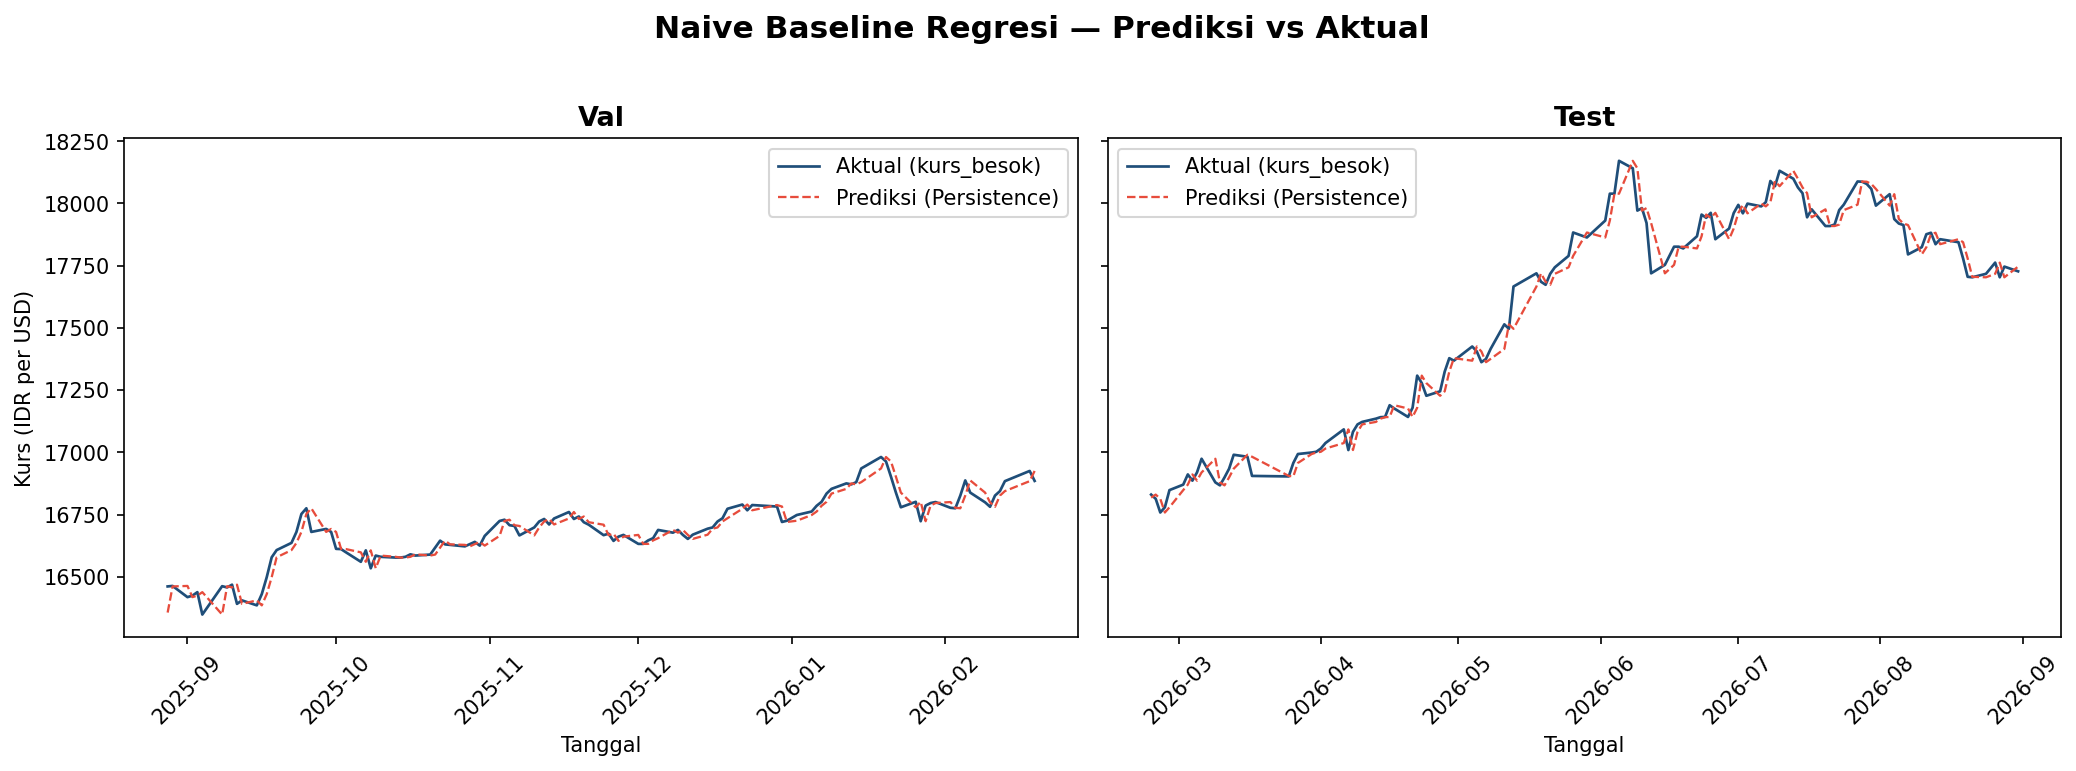


### Naive baseline — perbandingan regresi  (`naive_baseline_regression_comparison.png`)


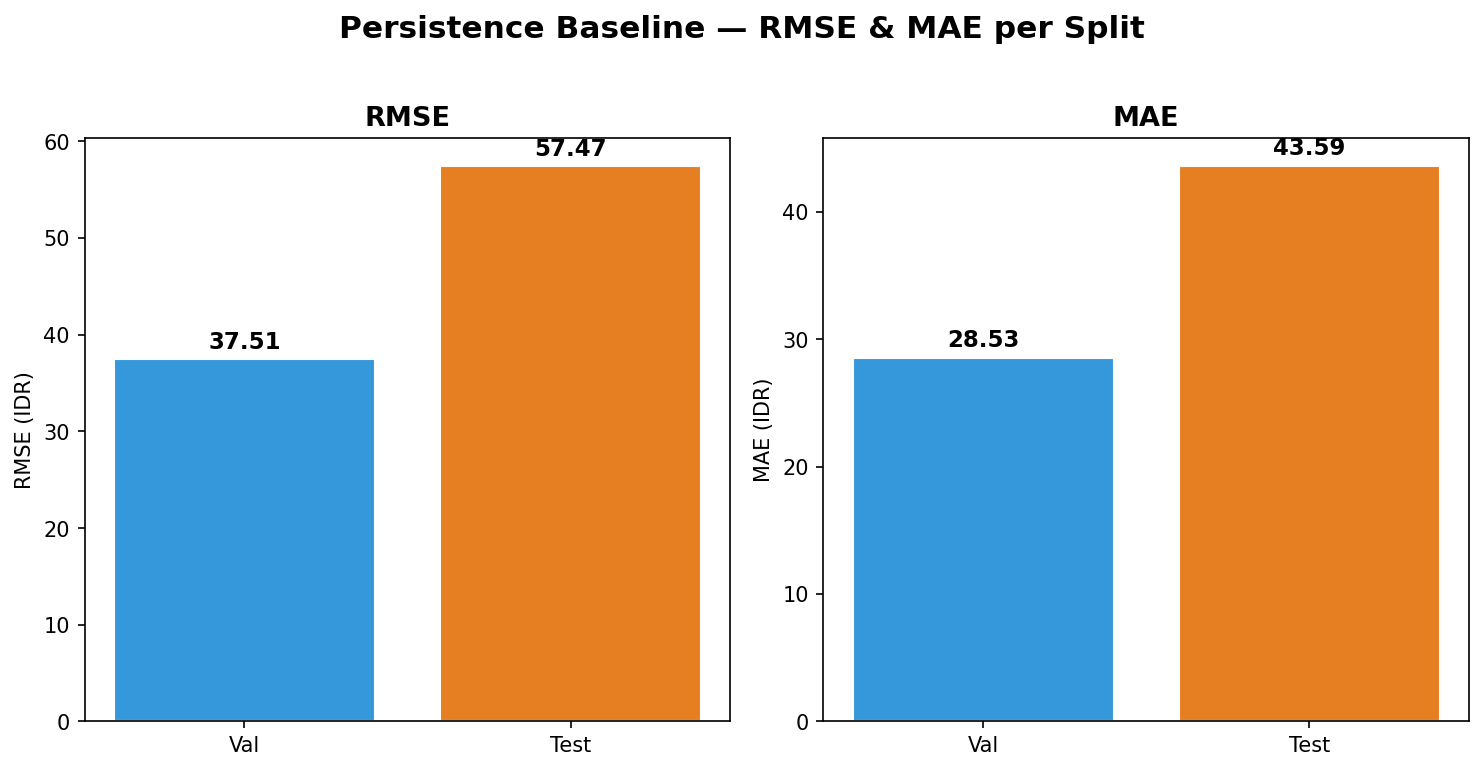


### Distribusi target per split  (`target_distribution.png`)


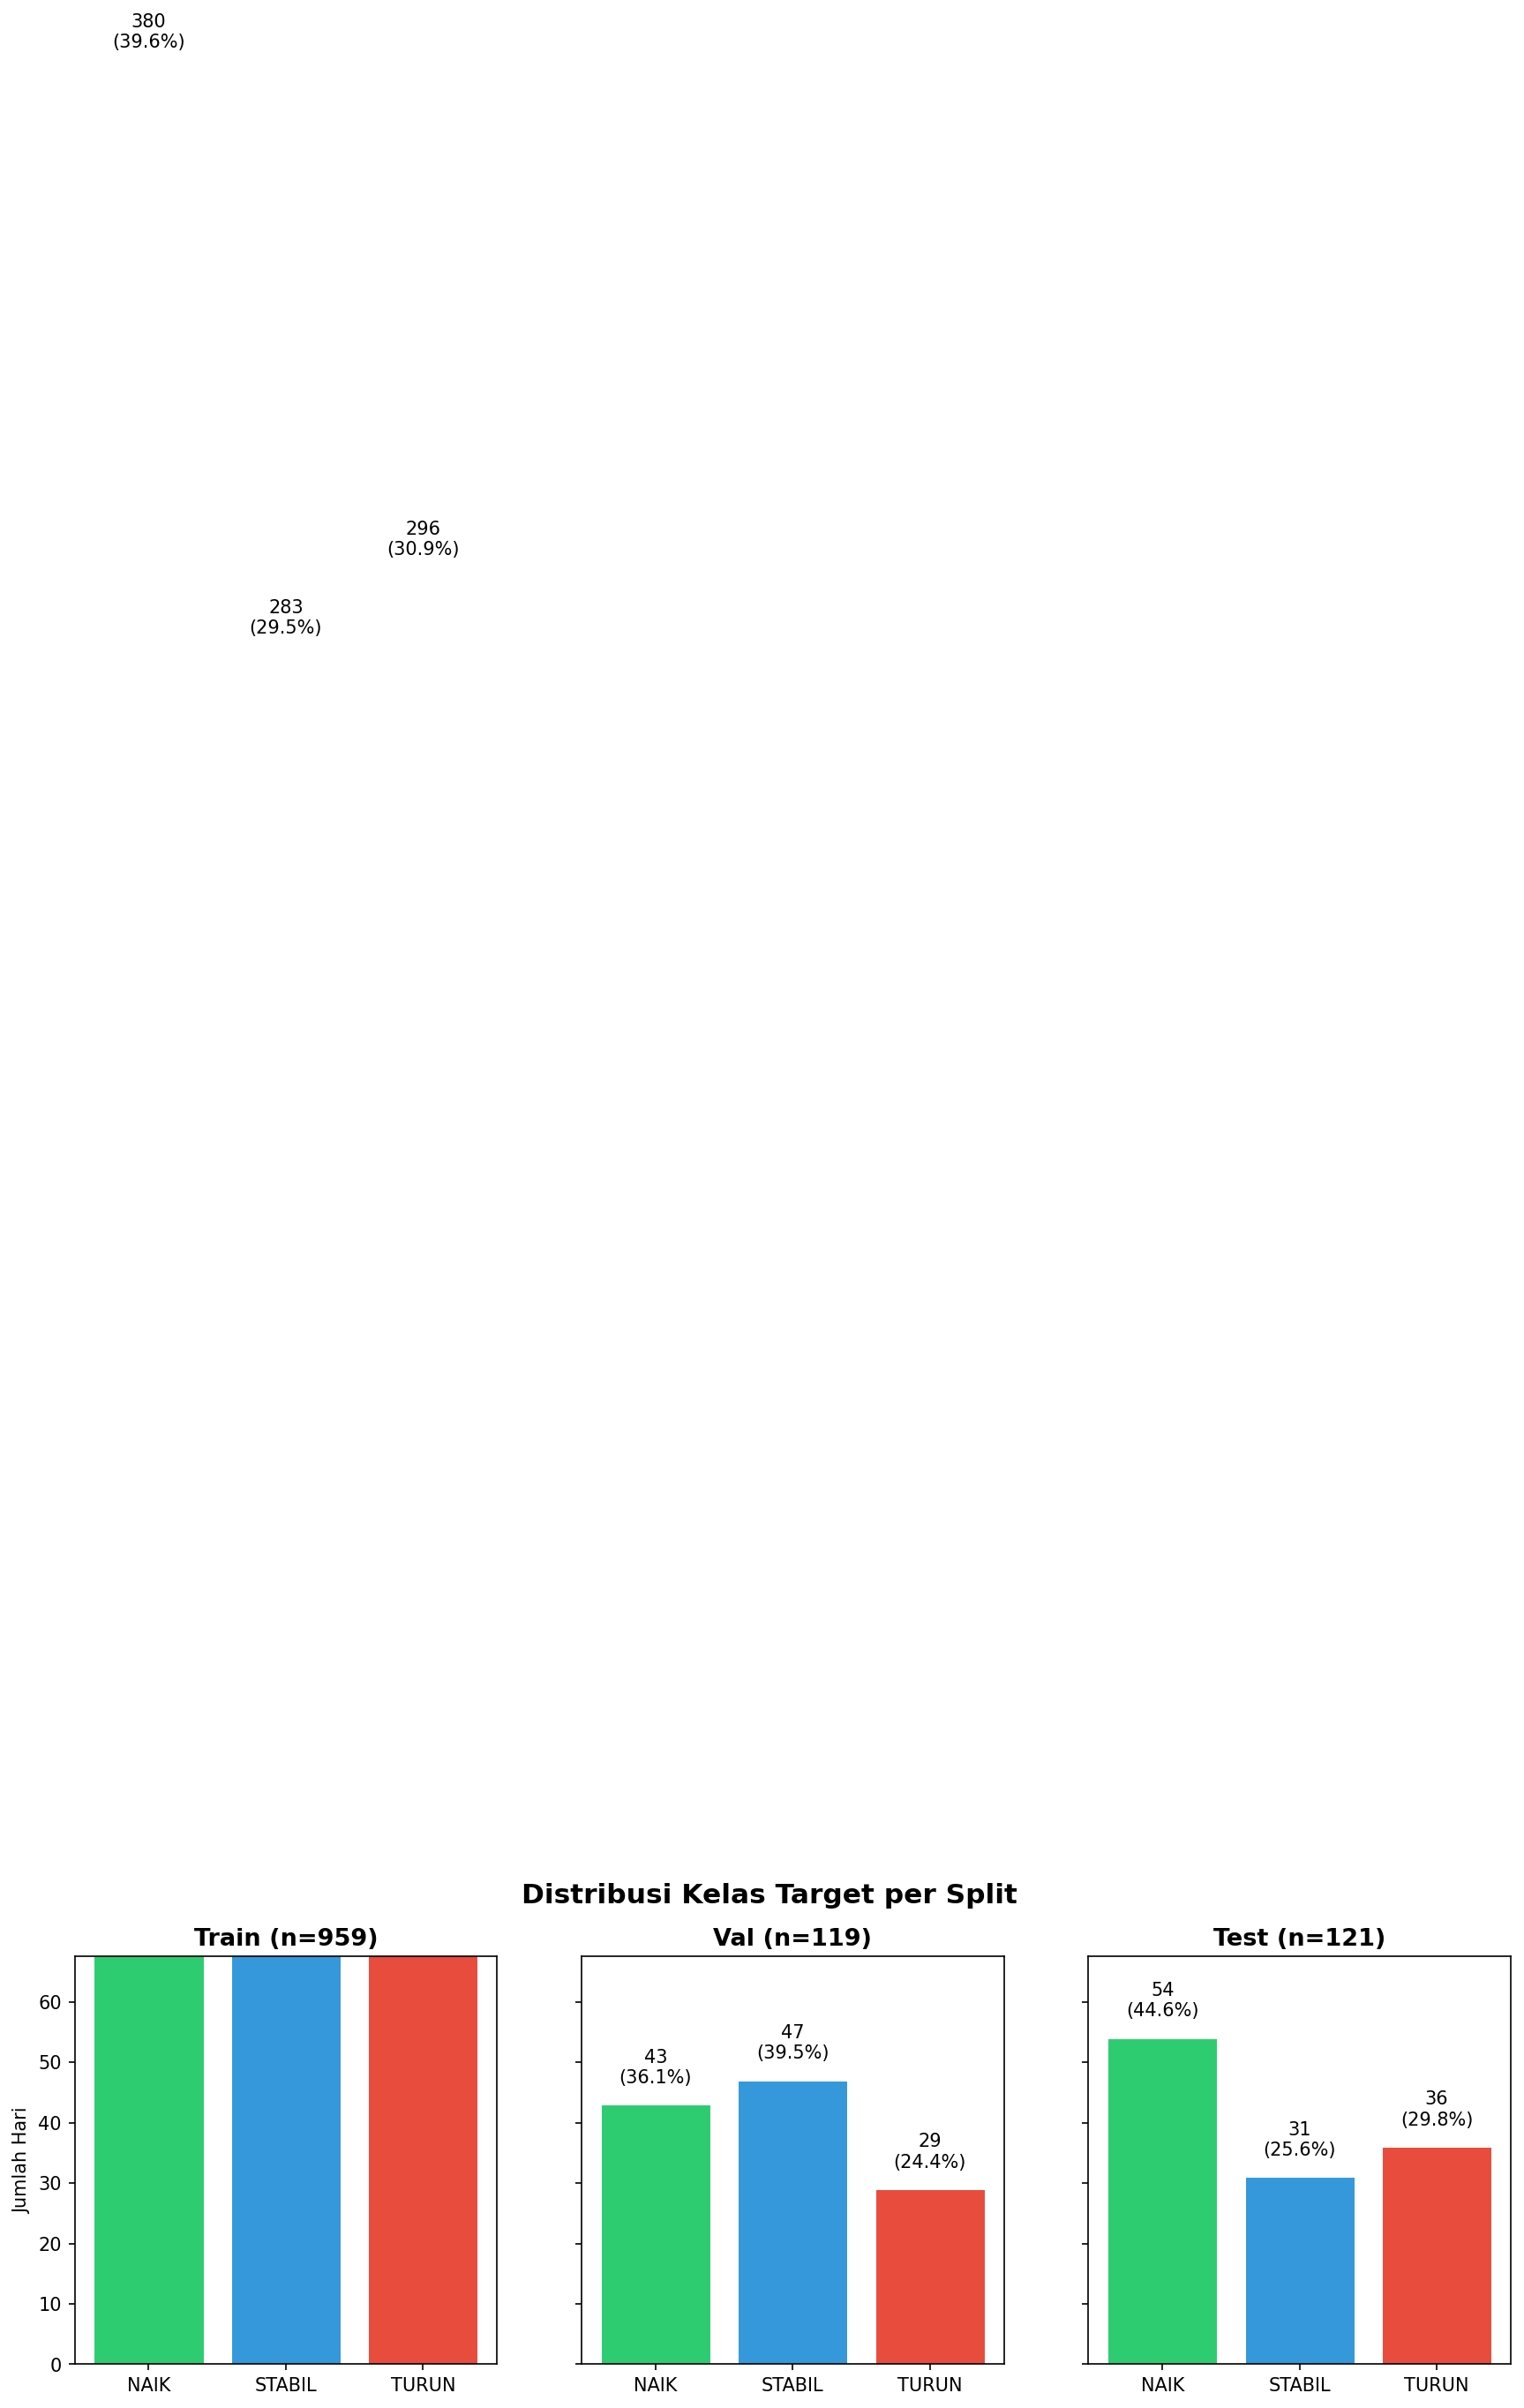

In [7]:
nb_clf = load_json("naive_baseline_results.json")["results"]
nb_reg = load_json("naive_baseline_regression_results.json")["results"]
print(f"Lower bound klasifikasi: Macro-F1 Test > {load_json('naive_baseline_results.json')['lower_bound_value']}")
print(f"Lower bound regresi    : RMSE Test < {load_json('naive_baseline_regression_results.json')['lower_bound_value']}")
for split in ("val", "test"):
    for key, label in (("persistence", "Persistence of Direction"), ("majority_class", "Majority-Class")):
        r = nb_clf[split][key]
        print(f"  clf {split:4s} {label:26s} acc={r['accuracy']:.4f} macroF1={r['macro_f1']:.4f}")
for split in ("val", "test"):
    r = nb_reg[split]["persistence"]
    print(f"  reg {split:4s} Persistence (Random Walk)  rmse={r['rmse']:.4f} mae={r['mae']:.4f}")

for fname, cap in [
    ("naive_baseline_confusion_matrix.png", "Naive baseline — confusion matrix"),
    ("naive_baseline_comparison.png", "Naive baseline — perbandingan klasifikasi"),
    ("naive_baseline_regression_prediction.png", "Naive baseline — prediksi vs aktual (regresi)"),
    ("naive_baseline_regression_comparison.png", "Naive baseline — perbandingan regresi"),
    ("target_distribution.png", "Distribusi target per split"),
]:
    if (RES / fname).exists():
        show_png(fname, cap)


## 7. Kesimpulan otomatis — siapa mengalahkan baseline?

Dihitung dari CSV superset `06_nlp_only_comparison.csv` (fair, same-rows): klasifikasi vs naive-persistence Macro-F1 **Test 0.3562**, regresi vs naive RMSE **Test 51.1231**.

In [8]:
base_clf = float(comp[(comp.model == "Naive Persistence of Direction") & (comp.split == "test") & (comp.task == "clf")]["macro_f1"].iloc[0])
base_reg = float(comp[(comp.model == "Naive Persistence (Random Walk)") & (comp.split == "test") & (comp.task == "reg")]["rmse"].iloc[0])
print(f"Acuan same-rows Test: Macro-F1={base_clf}, RMSE={base_reg} | Kanonis full-split: 0.3637 / 57.4694\n")

verdict = []
for m in ["XGBoost TS-only", "XGBoost NLP-only", "XGBoost Gabungan (TS+NLP)"]:
    f1 = float(comp[(comp.model == m) & (comp.split == "test") & (comp.task == "clf")]["macro_f1"].iloc[0])
    rm = float(comp[(comp.model == m) & (comp.split == "test") & (comp.task == "reg")]["rmse"].iloc[0])
    sk = float(comp[(comp.model == m) & (comp.split == "test") & (comp.task == "reg")]["skill_vs_naive"].iloc[0])
    verdict.append({
        "model": m,
        "clf_Test_F1": round(f1, 4),
        "clf_kalahkan_naive_same_rows": bool(f1 > base_clf),
        "reg_Test_RMSE": round(rm, 4),
        "reg_skill": round(sk, 4),
        "reg_kalahkan_naive": bool(rm < base_reg),
    })
display(pd.DataFrame(verdict))
print("Catatan regresi: ketiga XGBoost mengalahkan naive (skill > 0) meski tipis (+0.2% s.d. +0.8%) — "
      "konsisten dengan sifat random-walk FX harian.")
print("Catatan klasifikasi: hanya TS-only yang di atas naive same-rows (0.3626 > 0.3562); "
      "tak ada yang menembus bound kanonis full-split 0.3637.")


Acuan same-rows Test: Macro-F1=0.3562, RMSE=51.1231 | Kanonis full-split: 0.3637 / 57.4694



,model,clf_Test_F1,clf_kalahkan_naive_same_rows,reg_Test_RMSE,reg_skill,reg_kalahkan_naive
0,XGBoost TS-only,0.3626,True,50.9977,0.0025,True
1,XGBoost NLP-only,0.2856,False,50.7325,0.0076,True
2,XGBoost Gabungan (TS+NLP),0.2938,False,50.8200,0.0059,True


Catatan regresi: ketiga XGBoost mengalahkan naive (skill > 0) meski tipis (+0.2% s.d. +0.8%) — konsisten dengan sifat random-walk FX harian.
Catatan klasifikasi: hanya TS-only yang di atas naive same-rows (0.3626 > 0.3562); tak ada yang menembus bound kanonis full-split 0.3637.
